In [8]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [9]:
import importlib.util

packages = {
    "segmentation_models_pytorch": "segmentation-models-pytorch",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "sklearn": "scikit-learn"
}

for module_name, package_name in packages.items():
    installed = importlib.util.find_spec(module_name) is not None
    print(f"{package_name}: {'installed' if installed else 'missing'}")

segmentation-models-pytorch: installed
opencv-python: installed
Pillow: installed
scikit-learn: installed


In [10]:
!pip install -q segmentation-models-pytorch

In [11]:
import segmentation_models_pytorch as smp

print("SMP version:", smp.__version__)
print("SMP imported successfully")

SMP version: 0.5.0
SMP imported successfully


In [12]:
import segmentation_models_pytorch as smp

print("SMP version:", smp.__version__)
print("SMP imported successfully")


SMP version: 0.5.0
SMP imported successfully


In [13]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())
print("Files:")
for p in sorted(DATA_DIR.iterdir()):
    print(" -", p.name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/PathoScope/data
Exists: True
Files:
 - benchmark_stainnorm.json
 - notebook_03_results
 - ref_stain.npz
 - tiles.csv
 - tiles_img.zip
 - tiles_mask.zip
 - tiles_norm.zip


In [14]:
TILES_CSV = DATA_DIR / "tiles.csv"
TILES_NORM_ZIP = DATA_DIR / "tiles_norm.zip"
TILES_MASK_ZIP = DATA_DIR / "tiles_mask.zip"

df = pd.read_csv(TILES_CSV)

print("tiles.csv shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nRequired files:")
print("tiles.csv:", TILES_CSV.exists())
print("tiles_norm.zip:", TILES_NORM_ZIP.exists())
print("tiles_mask.zip:", TILES_MASK_ZIP.exists())

print("\nTile label counts:")
print(df["tile_label"].value_counts(dropna=False).sort_index())

print("\nMask availability:")
print(df["mask_available"].value_counts(dropna=False))

tiles.csv shape: (12800, 13)

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

Required files:
tiles.csv: True
tiles_norm.zip: True
tiles_mask.zip: True

Tile label counts:
tile_label
-1     838
 0    8569
 1    3393
Name: count, dtype: int64

Mask availability:
mask_available
1    12800
Name: count, dtype: int64


In [15]:
import zipfile
from PIL import Image
from io import BytesIO

with zipfile.ZipFile(TILES_MASK_ZIP, "r") as z:
    mask_files = [f for f in z.namelist() if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    print("Masks in ZIP:", len(mask_files))

    for name in mask_files[:5]:
        data = z.read(name)
        mask = np.array(Image.open(BytesIO(data)))

        print("\nFile:", name)
        print("Shape:", mask.shape)
        print("Dtype:", mask.dtype)
        print("Min:", mask.min())
        print("Max:", mask.max())
        print("Unique values:", np.unique(mask)[:20])


Masks in ZIP: 12800

File: c8ca4858e14ad4bc1a466796f147f1ca_x6656_y9216.png
Shape: (256, 256)
Dtype: uint8
Min: 1
Max: 1
Unique values: [1]

File: 0f1ea91c9f917bb3d198f02fd432e4ce_x1280_y1024.png
Shape: (256, 256)
Dtype: uint8
Min: 1
Max: 2
Unique values: [1 2]

File: f815e7ebafbbfa2578e3abadc8a5d15b_x10752_y1792.png
Shape: (256, 256)
Dtype: uint8
Min: 1
Max: 4
Unique values: [1 4]

File: ec550454bd72896fbbab24e1146cc904_x13568_y15872.png
Shape: (256, 256)
Dtype: uint8
Min: 0
Max: 0
Unique values: [0]

File: a0c04a4f156d76aa695bb9264c1bc0b9_x19712_y15360.png
Shape: (256, 256)
Dtype: uint8
Min: 1
Max: 1
Unique values: [1]


In [16]:
from collections import Counter

value_counts = Counter()
mask_stats = []

with zipfile.ZipFile(TILES_MASK_ZIP, "r") as z:
    for name in mask_files:
        data = z.read(name)
        mask = np.array(Image.open(BytesIO(data)))

        values, counts = np.unique(mask, return_counts=True)

        for value, count in zip(values, counts):
            value_counts[int(value)] += int(count)

        mask_stats.append({
            "mask_file": name,
            "unique_values": values.tolist(),
            "nonzero_pixels": int(np.count_nonzero(mask)),
            "total_pixels": int(mask.size),
            "nonzero_fraction": float(np.count_nonzero(mask) / mask.size)
        })

print("All mask pixel values:")
for value, count in sorted(value_counts.items()):
    print(f"Value {value}: {count:,} pixels")

mask_stats_df = pd.DataFrame(mask_stats)

print("\nNumber of masks:", len(mask_stats_df))
print("\nMasks by unique-value pattern:")
print(mask_stats_df["unique_values"].astype(str).value_counts())

All mask pixel values:
Value 0: 67,826,819 pixels
Value 1: 647,076,396 pixels
Value 2: 79,572,353 pixels
Value 3: 6,475,604 pixels
Value 4: 31,154,584 pixels
Value 5: 6,755,044 pixels

Number of masks: 12800

Masks by unique-value pattern:
unique_values
[1]                7148
[1, 4]             1112
[2]                1027
[1, 2]              933
[0]                 838
[1, 3]              491
[0, 1]              390
[1, 5]              316
[0, 2]              142
[0, 1, 2]            98
[1, 3, 4]            80
[1, 4, 5]            64
[1, 2, 3]            56
[0, 1, 4]            49
[1, 2, 4]            16
[0, 1, 3]            13
[1, 2, 5]             9
[1, 2, 3, 4]          5
[0, 1, 2, 4]          5
[1, 2, 4, 5]          2
[0, 1, 5]             2
[0, 1, 2, 3]          2
[0, 1, 2, 4, 5]       1
[1, 3, 5]             1
Name: count, dtype: int64


Tile ID: 8f264374ed3fa427615c1650218e7f21_x1536_y1536
Image shape: (256, 256, 3)
Mask shape: (256, 256)
Mask values: [1]
Tile label: 0
ISUP grade: 1


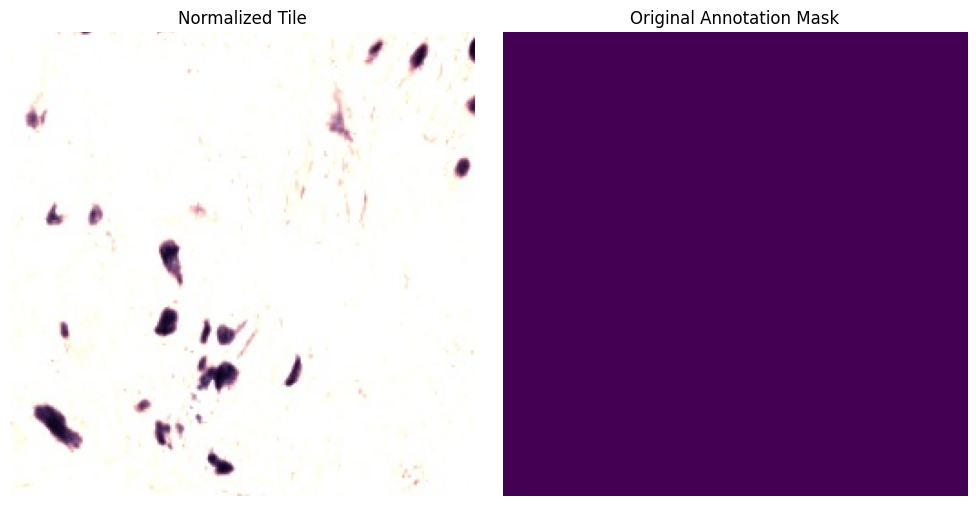

In [17]:
import matplotlib.pyplot as plt

sample = df.iloc[0]

tile_id = sample["tile_id"]

with zipfile.ZipFile(TILES_NORM_ZIP, "r") as img_zip:
    image_name = f"{tile_id}.jpg"
    image = np.array(Image.open(BytesIO(img_zip.read(image_name))).convert("RGB"))

with zipfile.ZipFile(TILES_MASK_ZIP, "r") as mask_zip:
    mask_name = f"{tile_id}.png"
    mask = np.array(Image.open(BytesIO(mask_zip.read(mask_name))))

print("Tile ID:", tile_id)
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))
print("Tile label:", sample["tile_label"])
print("ISUP grade:", sample["isup_grade"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image)
axes[0].set_title("Normalized Tile")
axes[0].axis("off")

axes[1].imshow(mask)
axes[1].set_title("Original Annotation Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Tile ID: 051a2228aadbb0d44e61f8507114a4c0_x32256_y16896
Tile label: 1
ISUP grade: 4
Mask values: [1 2 5]


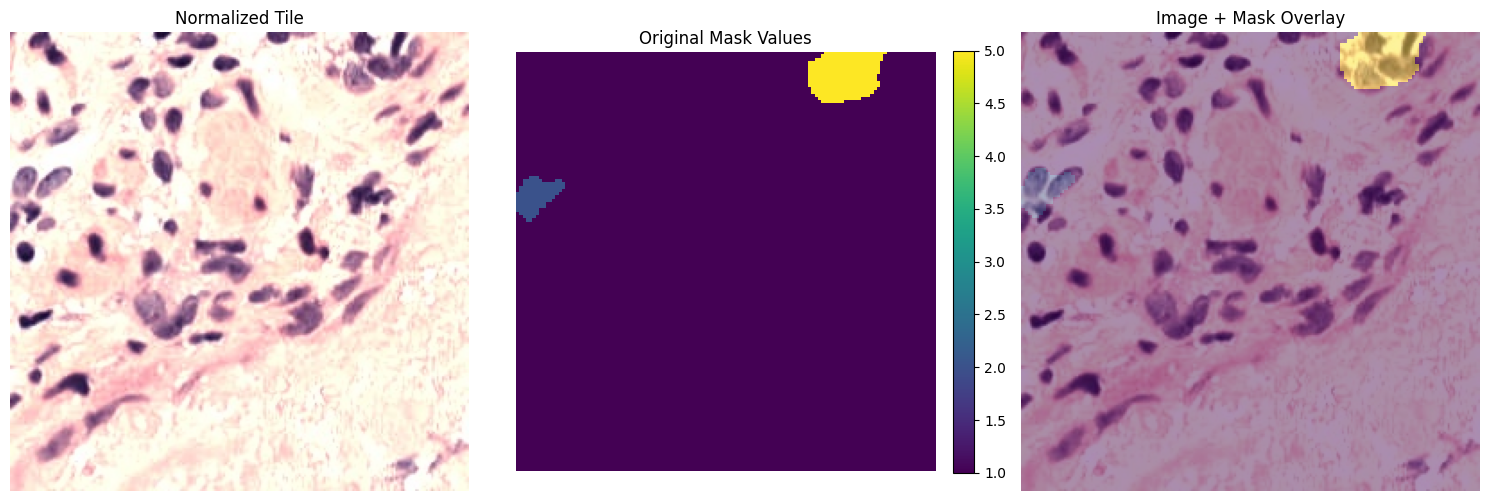

In [18]:
# Find a tile whose mask contains multiple values
selected = None

with zipfile.ZipFile(TILES_MASK_ZIP, "r") as mask_zip:
    for name in mask_files:
        mask = np.array(Image.open(BytesIO(mask_zip.read(name))))
        values = np.unique(mask)

        if len(values) >= 3:
            selected = (name, mask)
            break

if selected is None:
    print("No mask with 3 or more values found.")
else:
    mask_name, mask = selected
    tile_id = Path(mask_name).stem

    with zipfile.ZipFile(TILES_NORM_ZIP, "r") as img_zip:
        image = np.array(
            Image.open(
                BytesIO(img_zip.read(f"{tile_id}.jpg"))
            ).convert("RGB")
        )

    row = df[df["tile_id"] == tile_id].iloc[0]

    print("Tile ID:", tile_id)
    print("Tile label:", row["tile_label"])
    print("ISUP grade:", row["isup_grade"])
    print("Mask values:", np.unique(mask))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Normalized Tile")
    axes[0].axis("off")

    im = axes[1].imshow(mask, interpolation="nearest")
    axes[1].set_title("Original Mask Values")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(image)
    axes[2].imshow(mask, alpha=0.45, interpolation="nearest")
    axes[2].set_title("Image + Mask Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [19]:
mask_summary = []

with zipfile.ZipFile(TILES_MASK_ZIP, "r") as mask_zip:
    for name in mask_files:
        mask = np.array(Image.open(BytesIO(mask_zip.read(name))))

        binary_mask = (mask > 0).astype(np.uint8)

        mask_summary.append({
            "tile_id": Path(name).stem,
            "original_values": ",".join(map(str, np.unique(mask))),
            "positive_pixels": int(binary_mask.sum()),
            "positive_fraction": float(binary_mask.mean())
        })

mask_summary_df = pd.DataFrame(mask_summary)

print("Total masks:", len(mask_summary_df))
print("Masks containing positive pixels:",
      (mask_summary_df["positive_pixels"] > 0).sum())
print("Completely empty masks:",
      (mask_summary_df["positive_pixels"] == 0).sum())

print("\nPositive-pixel fraction:")
print(mask_summary_df["positive_fraction"].describe())

print("\nBy tile_label:")
summary_by_label = (
    mask_summary_df
    .merge(df[["tile_id", "tile_label"]], on="tile_id")
    .groupby("tile_label")["positive_fraction"]
    .agg(["count", "mean", "median", "min", "max"])
)

print(summary_by_label)

Total masks: 12800
Masks containing positive pixels: 11962
Completely empty masks: 838

Positive-pixel fraction:
count    12800.000000
mean         0.919144
std          0.262031
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: positive_fraction, dtype: float64

By tile_label:
            count      mean  median       min  max
tile_label                                        
-1            838  0.000000     0.0  0.000000  0.0
 0           8569  0.984481     1.0  0.000305  1.0
 1           3393  0.981146     1.0  0.003906  1.0


In [20]:
tumor_summary = []

with zipfile.ZipFile(TILES_MASK_ZIP, "r") as mask_zip:
    for name in mask_files:
        tile_id = Path(name).stem

        row = df[df["tile_id"] == tile_id].iloc[0]
        provider = str(row["data_provider"]).lower()

        mask = np.array(
            Image.open(BytesIO(mask_zip.read(name)))
        )

        if "radboud" in provider:
            tumor_mask = mask >= 3
        elif "karolinska" in provider:
            tumor_mask = mask == 2
        else:
            raise ValueError(f"Unknown provider: {provider}")

        tumor_summary.append({
            "tile_id": tile_id,
            "data_provider": provider,
            "tile_label": row["tile_label"],
            "isup_grade": row["isup_grade"],
            "tumor_pixels": int(tumor_mask.sum()),
            "tumor_fraction": float(tumor_mask.mean())
        })

tumor_summary_df = pd.DataFrame(tumor_summary)

print("Total tiles:", len(tumor_summary_df))

print("\nTiles containing tumor pixels:")
print(
    (tumor_summary_df["tumor_pixels"] > 0).sum()
)

print("\nTiles with no tumor pixels:")
print(
    (tumor_summary_df["tumor_pixels"] == 0).sum()
)

print("\nTumor fraction:")
print(tumor_summary_df["tumor_fraction"].describe())

print("\nBy data provider:")
print(
    tumor_summary_df
    .groupby("data_provider")["tumor_fraction"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("\nBy tile label:")
print(
    tumor_summary_df
    .groupby("tile_label")["tumor_fraction"]
    .agg(["count", "mean", "median", "min", "max"])
)

Total tiles: 12800

Tiles containing tumor pixels:
3393

Tiles with no tumor pixels:
9407

Tumor fraction:
count    12800.000000
mean         0.140009
std          0.307571
min          0.000000
25%          0.000000
50%          0.000000
75%          0.011047
max          1.000000
Name: tumor_fraction, dtype: float64

By data provider:
               count      mean  median  min       max
data_provider                                        
karolinska      6400  0.174196     0.0  0.0  1.000000
radboud         6400  0.105823     0.0  0.0  0.996277

By tile label:
            count      mean   median       min  max
tile_label                                         
-1            838  0.000000  0.00000  0.000000  0.0
 0           8569  0.000000  0.00000  0.000000  0.0
 1           3393  0.528181  0.47583  0.000061  1.0


In [21]:
from sklearn.model_selection import train_test_split

# One row per slide
slide_df = (
    df[["image_id", "isup_grade"]]
    .drop_duplicates()
    .sort_values("image_id")
    .reset_index(drop=True)
)

print("Total slides:", len(slide_df))

# 70% train, 30% temporary
train_slides, temp_slides = train_test_split(
    slide_df,
    test_size=0.30,
    random_state=42,
    stratify=slide_df["isup_grade"]
)

# Split remaining 30% equally into validation and test
val_slides, test_slides = train_test_split(
    temp_slides,
    test_size=0.50,
    random_state=42,
    stratify=temp_slides["isup_grade"]
)

train_ids = set(train_slides["image_id"])
val_ids = set(val_slides["image_id"])
test_ids = set(test_slides["image_id"])

print("\nTrain slides:", len(train_ids))
print("Validation slides:", len(val_ids))
print("Test slides:", len(test_ids))

print("\nLeakage checks:")
print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))

# Convert slide split to tile split
train_df = df[df["image_id"].isin(train_ids)].copy()
val_df = df[df["image_id"].isin(val_ids)].copy()
test_df = df[df["image_id"].isin(test_ids)].copy()

print("\nTile counts:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Total slides: 200

Train slides: 140
Validation slides: 30
Test slides: 30

Leakage checks:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0

Tile counts:
Train: 8960
Validation: 1920
Test: 1920


In [22]:
for name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    tumor_tiles = (split_df["tile_label"] == 1).sum()
    non_tumor_tiles = (split_df["tile_label"] != 1).sum()

    print(f"{name}:")
    print(f"  Total tiles: {len(split_df)}")
    print(f"  Tumor tiles: {tumor_tiles}")
    print(f"  Non-tumor tiles: {non_tumor_tiles}")
    print(f"  Tumor percentage: {100 * tumor_tiles / len(split_df):.2f}%")
    print()

Train:
  Total tiles: 8960
  Tumor tiles: 2410
  Non-tumor tiles: 6550
  Tumor percentage: 26.90%

Validation:
  Total tiles: 1920
  Tumor tiles: 457
  Non-tumor tiles: 1463
  Tumor percentage: 23.80%

Test:
  Total tiles: 1920
  Tumor tiles: 526
  Non-tumor tiles: 1394
  Tumor percentage: 27.40%



In [23]:
from pathlib import Path
import zipfile

WORK_DIR = Path("/content/pathoscope_04")
NORM_DIR = WORK_DIR / "tiles_norm"
MASK_DIR = WORK_DIR / "masks"

WORK_DIR.mkdir(parents=True, exist_ok=True)
NORM_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

# Extract normalized images
with zipfile.ZipFile(TILES_NORM_ZIP, "r") as z:
    z.extractall(NORM_DIR)

# Extract masks
with zipfile.ZipFile(TILES_MASK_ZIP, "r") as z:
    z.extractall(MASK_DIR)

norm_files = list(NORM_DIR.glob("*.jpg"))
mask_files_local = list(MASK_DIR.glob("*.png"))

print("Normalized images:", len(norm_files))
print("Masks:", len(mask_files_local))

print("\nExample normalized image:")
print(norm_files[0])

print("\nExample mask:")
print(mask_files_local[0])

print("\nStorage:")
print("Normalized directory:", NORM_DIR)
print("Mask directory:", MASK_DIR)

Normalized images: 12800
Masks: 12800

Example normalized image:
/content/pathoscope_04/tiles_norm/7a40364bb1370598575caac647f1635f_x5888_y8704.jpg

Example mask:
/content/pathoscope_04/masks/0d19c87a2ac19e41556441cdfafd7234_x2560_y10752.png

Storage:
Normalized directory: /content/pathoscope_04/tiles_norm
Mask directory: /content/pathoscope_04/masks


In [24]:
norm_ids = {p.stem for p in NORM_DIR.glob("*.jpg")}
mask_ids = {p.stem for p in MASK_DIR.glob("*.png")}
csv_ids = set(df["tile_id"].astype(str))

print("CSV tile IDs:", len(csv_ids))
print("Normalized image IDs:", len(norm_ids))
print("Mask IDs:", len(mask_ids))

print("\nCSV ↔ normalized:")
print("Missing normalized:", len(csv_ids - norm_ids))
print("Extra normalized:", len(norm_ids - csv_ids))

print("\nCSV ↔ masks:")
print("Missing masks:", len(csv_ids - mask_ids))
print("Extra masks:", len(mask_ids - csv_ids))

print("\nAll mappings valid:",
      csv_ids == norm_ids == mask_ids)

CSV tile IDs: 12800
Normalized image IDs: 12800
Mask IDs: 12800

CSV ↔ normalized:
Missing normalized: 0
Extra normalized: 0

CSV ↔ masks:
Missing masks: 0
Extra masks: 0

All mappings valid: True


In [25]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import numpy as np


class PathoScopeSegmentationDataset(Dataset):
    def __init__(self, dataframe, image_dir, mask_dir, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.augment = augment

        self.image_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        tile_id = str(row["tile_id"])
        provider = str(row["data_provider"]).lower()

        image_path = self.image_dir / f"{tile_id}.jpg"
        mask_path = self.mask_dir / f"{tile_id}.png"

        image = Image.open(image_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        if "radboud" in provider:
            tumor_mask = mask >= 3
        elif "karolinska" in provider:
            tumor_mask = mask == 2
        else:
            raise ValueError(f"Unknown provider: {provider}")

        tumor_mask = tumor_mask.astype(np.float32)

        image = np.array(image)

        if self.augment:
            if np.random.random() < 0.5:
                image = np.fliplr(image).copy()
                tumor_mask = np.fliplr(tumor_mask).copy()

            if np.random.random() < 0.5:
                image = np.flipud(image).copy()
                tumor_mask = np.flipud(tumor_mask).copy()

        image = self.image_transform(Image.fromarray(image))

        mask_tensor = torch.from_numpy(tumor_mask).unsqueeze(0)

        return {
            "image": image,
            "mask": mask_tensor,
            "tile_id": tile_id
        }


print("PathoScopeSegmentationDataset defined successfully")

PathoScopeSegmentationDataset defined successfully


In [26]:
print("Total rows in df:", len(df))
print("Total unique slides:", df["image_id"].nunique())

print("train_slides type:", type(train_slides))
print("Number of train slides:", len(train_slides))

print("First 5 train slides:")
print(list(train_slides)[:5])

train_df = df[df["image_id"].isin(train_slides)].copy()

print("\nTrain dataframe rows:", len(train_df))
print("Train dataframe unique slides:", train_df["image_id"].nunique())

Total rows in df: 12800
Total unique slides: 200
train_slides type: <class 'pandas.core.frame.DataFrame'>
Number of train slides: 140
First 5 train slides:
['image_id', 'isup_grade']

Train dataframe rows: 0
Train dataframe unique slides: 0


In [27]:
from sklearn.model_selection import train_test_split

slide_df = (
    df[["image_id", "isup_grade"]]
    .drop_duplicates()
    .sort_values("image_id")
    .reset_index(drop=True)
)

train_slide_df, temp_slide_df = train_test_split(
    slide_df,
    test_size=0.30,
    random_state=42,
    stratify=slide_df["isup_grade"]
)

val_slide_df, test_slide_df = train_test_split(
    temp_slide_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_slide_df["isup_grade"]
)

train_slide_ids = set(train_slide_df["image_id"])
val_slide_ids = set(val_slide_df["image_id"])
test_slide_ids = set(test_slide_df["image_id"])

print("Total slides:", len(slide_df))
print("Train slides:", len(train_slide_ids))
print("Validation slides:", len(val_slide_ids))
print("Test slides:", len(test_slide_ids))

print("\nTrain ∩ Validation:", len(train_slide_ids & val_slide_ids))
print("Train ∩ Test:", len(train_slide_ids & test_slide_ids))
print("Validation ∩ Test:", len(val_slide_ids & test_slide_ids))

Total slides: 200
Train slides: 140
Validation slides: 30
Test slides: 30

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [28]:
train_df = df[df["image_id"].isin(train_slide_ids)].copy().reset_index(drop=True)
val_df = df[df["image_id"].isin(val_slide_ids)].copy().reset_index(drop=True)
test_df = df[df["image_id"].isin(test_slide_ids)].copy().reset_index(drop=True)

print("Train tiles:", len(train_df))
print("Validation tiles:", len(val_df))
print("Test tiles:", len(test_df))

print("\nTrain slides:", train_df["image_id"].nunique())
print("Validation slides:", val_df["image_id"].nunique())
print("Test slides:", test_df["image_id"].nunique())

print("\nTrain tumor tiles:", (train_df["tile_label"] == 1).sum())
print("Validation tumor tiles:", (val_df["tile_label"] == 1).sum())
print("Test tumor tiles:", (test_df["tile_label"] == 1).sum())

Train tiles: 8960
Validation tiles: 1920
Test tiles: 1920

Train slides: 140
Validation slides: 30
Test slides: 30

Train tumor tiles: 2410
Validation tumor tiles: 457
Test tumor tiles: 526


In [29]:
train_dataset = PathoScopeSegmentationDataset(
    dataframe=train_df,
    image_dir=NORM_DIR,
    mask_dir=MASK_DIR,
    augment=True
)

val_dataset = PathoScopeSegmentationDataset(
    dataframe=val_df,
    image_dir=NORM_DIR,
    mask_dir=MASK_DIR,
    augment=False
)

test_dataset = PathoScopeSegmentationDataset(
    dataframe=test_df,
    image_dir=NORM_DIR,
    mask_dir=MASK_DIR,
    augment=False
)

sample = train_dataset[0]

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("\nSample tile ID:", sample["tile_id"])
print("Image shape:", sample["image"].shape)
print("Image dtype:", sample["image"].dtype)
print("Mask shape:", sample["mask"].shape)
print("Mask dtype:", sample["mask"].dtype)
print("Mask unique values:", torch.unique(sample["mask"]).tolist())
print("Image min:", round(sample["image"].min().item(), 4))
print("Image max:", round(sample["image"].max().item(), 4))

Train dataset: 8960
Validation dataset: 1920
Test dataset: 1920

Sample tile ID: 871f73f44e29b8f3da8048aaf387a673_x19200_y5632
Image shape: torch.Size([3, 256, 256])
Image dtype: torch.float32
Mask shape: torch.Size([1, 256, 256])
Mask dtype: torch.float32
Mask unique values: [0.0]
Image min: -1.9132
Image max: 2.64


In [30]:
tumor_indices = train_df.index[
    train_df["tile_label"] == 1
].tolist()

tumor_dataset = PathoScopeSegmentationDataset(
    dataframe=train_df[train_df["tile_label"] == 1].reset_index(drop=True),
    image_dir=NORM_DIR,
    mask_dir=MASK_DIR,
    augment=False
)

tumor_sample = tumor_dataset[0]

print("Tumor-positive samples:", len(tumor_dataset))
print("Sample tile ID:", tumor_sample["tile_id"])
print("Image shape:", tumor_sample["image"].shape)
print("Mask shape:", tumor_sample["mask"].shape)
print("Mask unique values:", torch.unique(tumor_sample["mask"]).tolist())

tumor_pixels = tumor_sample["mask"].sum().item()
total_pixels = tumor_sample["mask"].numel()

print("Tumor pixels:", int(tumor_pixels))
print("Tumor fraction:", round(tumor_pixels / total_pixels, 6))

Tumor-positive samples: 2410
Sample tile ID: 871f73f44e29b8f3da8048aaf387a673_x24576_y21760
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Mask unique values: [1.0]
Tumor pixels: 65536
Tumor fraction: 1.0


In [31]:
train_tumor_fraction = []

for idx in range(len(train_df)):
    row = train_df.iloc[idx]

    tile_id = str(row["tile_id"])
    provider = str(row["data_provider"]).lower()

    mask_path = MASK_DIR / f"{tile_id}.png"
    mask = np.array(Image.open(mask_path))

    if "radboud" in provider:
        tumor_mask = mask >= 3
    elif "karolinska" in provider:
        tumor_mask = mask == 2
    else:
        raise ValueError(f"Unknown provider: {provider}")

    fraction = tumor_mask.mean()
    train_tumor_fraction.append(fraction)

train_tumor_fraction = np.array(train_tumor_fraction)

print("Training tiles:", len(train_tumor_fraction))
print("Tiles with tumor:", np.sum(train_tumor_fraction > 0))
print("Tiles without tumor:", np.sum(train_tumor_fraction == 0))

print("\nTumor fraction statistics:")
print("Mean:", round(train_tumor_fraction.mean(), 6))
print("Median:", round(np.median(train_tumor_fraction), 6))
print("Minimum:", round(train_tumor_fraction.min(), 6))
print("Maximum:", round(train_tumor_fraction.max(), 6))

print("\nTumor fraction > 0.5:",
      np.sum(train_tumor_fraction > 0.5))

Training tiles: 8960
Tiles with tumor: 2410
Tiles without tumor: 6550

Tumor fraction statistics:
Mean: 0.147317
Median: 0.0
Minimum: 0.0
Maximum: 1.0

Tumor fraction > 0.5: 1213


In [32]:
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(DEVICE)

print("Device:", DEVICE)
print("Model:", type(model).__name__)
print("Encoder: ResNet34")
print("Input channels:", 3)
print("Output channels:", 1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cuda
Model: Unet
Encoder: ResNet34
Input channels: 3
Output channels: 1
Total parameters: 24,436,369
Trainable parameters: 24,436,369


In [33]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

Train batches: 560
Validation batches: 120
Test batches: 120
Batch size: 16


In [34]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss: Dice + BCE")
print("Optimizer: Adam")
print("Learning rate:", 1e-4)

Loss: Dice + BCE
Optimizer: Adam
Learning rate: 0.0001


In [35]:
batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    logits = model(images)

loss_dice = dice_loss(logits, masks)
loss_bce = bce_loss(logits, masks)
loss_total = loss_dice + loss_bce

print("\nGPU:", torch.cuda.get_device_name(0))
print("Logits shape:", logits.shape)
print("Dice loss:", round(loss_dice.item(), 6))
print("BCE loss:", round(loss_bce.item(), 6))
print("Total loss:", round(loss_total.item(), 6))

Images shape: torch.Size([16, 3, 256, 256])
Masks shape: torch.Size([16, 1, 256, 256])

GPU: Tesla T4
Logits shape: torch.Size([16, 1, 256, 256])
Dice loss: 0.957668
BCE loss: 1.050922
Total loss: 2.00859


In [36]:
def calculate_batch_metrics(logits, masks, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).float()

    smooth = 1e-6

    intersection = (predictions * masks).sum(dim=(1, 2, 3))
    prediction_area = predictions.sum(dim=(1, 2, 3))
    mask_area = masks.sum(dim=(1, 2, 3))

    dice = (
        (2.0 * intersection + smooth) /
        (prediction_area + mask_area + smooth)
    )

    union = prediction_area + mask_area - intersection

    iou = (
        (intersection + smooth) /
        (union + smooth)
    )

    return dice.mean().item(), iou.mean().item()


def train_one_epoch(model, loader, optimizer, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)

        loss_dice = dice_loss(logits, masks)
        loss_bce = bce_loss(logits, masks)
        loss = loss_dice + loss_bce

        loss.backward()
        optimizer.step()

        dice, iou = calculate_batch_metrics(logits.detach(), masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

    n_batches = len(loader)

    return (
        running_loss / n_batches,
        running_dice / n_batches,
        running_iou / n_batches
    )


@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        logits = model(images)

        loss_dice = dice_loss(logits, masks)
        loss_bce = bce_loss(logits, masks)
        loss = loss_dice + loss_bce

        dice, iou = calculate_batch_metrics(logits, masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

    n_batches = len(loader)

    return (
        running_loss / n_batches,
        running_dice / n_batches,
        running_iou / n_batches
    )


print("Training functions defined successfully")

Training functions defined successfully


In [37]:
NUM_EPOCHS = 10
BEST_MODEL_PATH = WORK_DIR / "unet.pth"

best_val_dice = -1.0
training_history = []

print("Epochs:", NUM_EPOCHS)
print("Best model path:", BEST_MODEL_PATH)
print("Device:", DEVICE)

Epochs: 10
Best model path: /content/pathoscope_04/unet.pth
Device: cuda


In [38]:
import time

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_dice, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        DEVICE
    )

    val_loss, val_dice, val_iou = validate_one_epoch(
        model,
        val_loader,
        DEVICE
    )

    epoch_time = time.time() - start_time

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "val_loss": val_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "time_seconds": epoch_time
    })

    if val_dice > best_val_dice:
        best_val_dice = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou
            },
            BEST_MODEL_PATH
        )

        checkpoint_status = "saved"
    else:
        checkpoint_status = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Time: {epoch_time/60:.1f} min | "
        f"{checkpoint_status}"
    )

print("\nTraining complete.")
print("Best validation Dice:", round(best_val_dice, 4))
print("Best model:", BEST_MODEL_PATH)

Epoch 01/10 | Train Loss: 1.0433 | Train Dice: 0.4305 | Train IoU: 0.4052 | Val Loss: 0.5595 | Val Dice: 0.6824 | Val IoU: 0.6625 | Time: 2.0 min | saved
Epoch 02/10 | Train Loss: 0.8077 | Train Dice: 0.6658 | Train IoU: 0.6432 | Val Loss: 0.5634 | Val Dice: 0.7043 | Val IoU: 0.6849 | Time: 2.1 min | saved
Epoch 03/10 | Train Loss: 0.7466 | Train Dice: 0.7173 | Train IoU: 0.6963 | Val Loss: 0.5399 | Val Dice: 0.7989 | Val IoU: 0.7819 | Time: 2.2 min | saved
Epoch 04/10 | Train Loss: 0.7206 | Train Dice: 0.7399 | Train IoU: 0.7201 | Val Loss: 0.4993 | Val Dice: 0.7738 | Val IoU: 0.7554 | Time: 2.3 min | 
Epoch 05/10 | Train Loss: 0.7136 | Train Dice: 0.7443 | Train IoU: 0.7244 | Val Loss: 0.5338 | Val Dice: 0.6391 | Val IoU: 0.6198 | Time: 2.3 min | 
Epoch 06/10 | Train Loss: 0.6604 | Train Dice: 0.7570 | Train IoU: 0.7378 | Val Loss: 0.4889 | Val Dice: 0.7454 | Val IoU: 0.7261 | Time: 2.3 min | 
Epoch 07/10 | Train Loss: 0.6396 | Train Dice: 0.7657 | Train IoU: 0.7470 | Val Loss: 0.527

In [39]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

best_epoch = checkpoint["epoch"]
best_checkpoint_dice = checkpoint["val_dice"]
best_checkpoint_iou = checkpoint["val_iou"]

model = model.to(DEVICE)
model.eval()

print("Best checkpoint loaded successfully")
print("Best epoch:", best_epoch)
print("Validation Dice:", round(best_checkpoint_dice, 4))
print("Validation IoU:", round(best_checkpoint_iou, 4))
print("Model device:", next(model.parameters()).device)

Best checkpoint loaded successfully
Best epoch: 7
Validation Dice: 0.8041
Validation IoU: 0.7881
Model device: cuda:0


In [40]:
@torch.no_grad()
def evaluate_test_set(model, loader, device):
    model.eval()

    total_dice = 0.0
    total_iou = 0.0
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        logits = model(images)

        loss_dice = dice_loss(logits, masks)
        loss_bce = bce_loss(logits, masks)
        loss = loss_dice + loss_bce

        dice, iou = calculate_batch_metrics(logits, masks)

        total_loss += loss.item()
        total_dice += dice
        total_iou += iou
        n_batches += 1

    return (
        total_loss / n_batches,
        total_dice / n_batches,
        total_iou / n_batches
    )


test_loss, test_dice, test_iou = evaluate_test_set(
    model,
    test_loader,
    DEVICE
)

print("Baseline model: U-Net + ResNet34")
print("Test Loss:", round(test_loss, 4))
print("Test Dice:", round(test_dice, 4))
print("Test IoU:", round(test_iou, 4))

Baseline model: U-Net + ResNet34
Test Loss: 0.5021
Test Dice: 0.8262
Test IoU: 0.808


In [41]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "Model": "U-Net + ResNet34",
        "Parameters": sum(p.numel() for p in model.parameters()),
        "Val_Dice": best_checkpoint_dice,
        "Val_IoU": best_checkpoint_iou,
        "Test_Dice": test_dice,
        "Test_IoU": test_iou
    }
])

print(model_results.to_string(index=False))

           Model  Parameters  Val_Dice  Val_IoU  Test_Dice  Test_IoU
U-Net + ResNet34    24436369  0.804075 0.788126   0.826161  0.808048


In [42]:
model_r50 = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model_r50 = model_r50.to(DEVICE)

r50_params = sum(p.numel() for p in model_r50.parameters())

print("Model: U-Net + ResNet50")
print("Device:", DEVICE)
print("Total parameters:", f"{r50_params:,}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: U-Net + ResNet50
Device: cuda
Total parameters: 32,521,105


In [43]:
dice_loss_r50 = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss_r50 = torch.nn.BCEWithLogitsLoss()

optimizer_r50 = torch.optim.Adam(
    model_r50.parameters(),
    lr=1e-4
)

BEST_MODEL_R50 = WORK_DIR / "unet_resnet50.pth"

best_val_dice_r50 = -1.0
history_r50 = []

print("Model: U-Net + ResNet50")
print("Loss: Dice + BCE")
print("Optimizer: Adam")
print("Learning rate:", 1e-4)
print("Checkpoint:", BEST_MODEL_R50)

Model: U-Net + ResNet50
Loss: Dice + BCE
Optimizer: Adam
Learning rate: 0.0001
Checkpoint: /content/pathoscope_04/unet_resnet50.pth


In [44]:
import time

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    model_r50.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for batch in train_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        optimizer_r50.zero_grad()

        logits = model_r50(images)

        loss_dice = dice_loss_r50(logits, masks)
        loss_bce = bce_loss_r50(logits, masks)
        loss = loss_dice + loss_bce

        loss.backward()
        optimizer_r50.step()

        dice, iou = calculate_batch_metrics(logits.detach(), masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)
    train_iou = running_iou / len(train_loader)

    model_r50.eval()

    val_loss_total = 0.0
    val_dice_total = 0.0
    val_iou_total = 0.0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)

            logits = model_r50(images)

            loss_dice = dice_loss_r50(logits, masks)
            loss_bce = bce_loss_r50(logits, masks)
            loss = loss_dice + loss_bce

            dice, iou = calculate_batch_metrics(logits, masks)

            val_loss_total += loss.item()
            val_dice_total += dice
            val_iou_total += iou

    val_loss = val_loss_total / len(val_loader)
    val_dice = val_dice_total / len(val_loader)
    val_iou = val_iou_total / len(val_loader)

    epoch_time = time.time() - start_time

    history_r50.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "val_loss": val_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "time_seconds": epoch_time
    })

    if val_dice > best_val_dice_r50:
        best_val_dice_r50 = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_r50.state_dict(),
                "optimizer_state_dict": optimizer_r50.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou
            },
            BEST_MODEL_R50
        )

        checkpoint_status = "saved"
    else:
        checkpoint_status = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Time: {epoch_time/60:.1f} min | "
        f"{checkpoint_status}"
    )

print("\nResNet50 training complete.")
print("Best validation Dice:", round(best_val_dice_r50, 4))
print("Best model:", BEST_MODEL_R50)

Epoch 01/10 | Train Loss: 0.9305 | Train Dice: 0.5200 | Train IoU: 0.4959 | Val Loss: 0.5312 | Val Dice: 0.7251 | Val IoU: 0.7061 | Time: 3.7 min | saved
Epoch 02/10 | Train Loss: 0.7839 | Train Dice: 0.6826 | Train IoU: 0.6606 | Val Loss: 0.5401 | Val Dice: 0.6554 | Val IoU: 0.6342 | Time: 3.7 min | 
Epoch 03/10 | Train Loss: 0.7412 | Train Dice: 0.7040 | Train IoU: 0.6823 | Val Loss: 0.5105 | Val Dice: 0.7121 | Val IoU: 0.6931 | Time: 3.7 min | 
Epoch 04/10 | Train Loss: 0.7106 | Train Dice: 0.7138 | Train IoU: 0.6927 | Val Loss: 0.5417 | Val Dice: 0.6911 | Val IoU: 0.6740 | Time: 3.7 min | 
Epoch 05/10 | Train Loss: 0.6788 | Train Dice: 0.7344 | Train IoU: 0.7143 | Val Loss: 0.5322 | Val Dice: 0.7867 | Val IoU: 0.7710 | Time: 3.7 min | saved
Epoch 06/10 | Train Loss: 0.6753 | Train Dice: 0.7446 | Train IoU: 0.7247 | Val Loss: 0.4829 | Val Dice: 0.7549 | Val IoU: 0.7351 | Time: 3.7 min | 
Epoch 07/10 | Train Loss: 0.6272 | Train Dice: 0.7416 | Train IoU: 0.7224 | Val Loss: 0.7071 | V

In [45]:
model_unetpp = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model_unetpp = model_unetpp.to(DEVICE)

unetpp_params = sum(
    p.numel() for p in model_unetpp.parameters()
)

print("Model: U-Net++ + ResNet34")
print("Device:", DEVICE)
print("Total parameters:", f"{unetpp_params:,}")

Model: U-Net++ + ResNet34
Device: cuda
Total parameters: 26,078,609


In [46]:
dice_loss_unetpp = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss_unetpp = torch.nn.BCEWithLogitsLoss()

optimizer_unetpp = torch.optim.Adam(
    model_unetpp.parameters(),
    lr=1e-4
)

BEST_MODEL_UNETPP = WORK_DIR / "unetpp_resnet34.pth"

best_val_dice_unetpp = -1.0
history_unetpp = []

print("Model: U-Net++ + ResNet34")
print("Loss: Dice + BCE")
print("Optimizer: Adam")
print("Learning rate:", 1e-4)
print("Checkpoint:", BEST_MODEL_UNETPP)

Model: U-Net++ + ResNet34
Loss: Dice + BCE
Optimizer: Adam
Learning rate: 0.0001
Checkpoint: /content/pathoscope_04/unetpp_resnet34.pth


In [47]:
import time

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    model_unetpp.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for batch in train_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        optimizer_unetpp.zero_grad()

        logits = model_unetpp(images)

        loss_dice = dice_loss_unetpp(logits, masks)
        loss_bce = bce_loss_unetpp(logits, masks)
        loss = loss_dice + loss_bce

        loss.backward()
        optimizer_unetpp.step()

        dice, iou = calculate_batch_metrics(logits.detach(), masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)
    train_iou = running_iou / len(train_loader)

    model_unetpp.eval()

    val_loss_total = 0.0
    val_dice_total = 0.0
    val_iou_total = 0.0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)

            logits = model_unetpp(images)

            loss_dice = dice_loss_unetpp(logits, masks)
            loss_bce = bce_loss_unetpp(logits, masks)
            loss = loss_dice + loss_bce

            dice, iou = calculate_batch_metrics(logits, masks)

            val_loss_total += loss.item()
            val_dice_total += dice
            val_iou_total += iou

    val_loss = val_loss_total / len(val_loader)
    val_dice = val_dice_total / len(val_loader)
    val_iou = val_iou_total / len(val_loader)

    epoch_time = time.time() - start_time

    history_unetpp.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "val_loss": val_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "time_seconds": epoch_time
    })

    if val_dice > best_val_dice_unetpp:
        best_val_dice_unetpp = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_unetpp.state_dict(),
                "optimizer_state_dict": optimizer_unetpp.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou
            },
            BEST_MODEL_UNETPP
        )

        checkpoint_status = "saved"
    else:
        checkpoint_status = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Time: {epoch_time/60:.1f} min | "
        f"{checkpoint_status}"
    )

print("\nU-Net++ training complete.")
print("Best validation Dice:", round(best_val_dice_unetpp, 4))
print("Best model:", BEST_MODEL_UNETPP)

Epoch 01/10 | Train Loss: 0.9612 | Train Dice: 0.4513 | Train IoU: 0.4269 | Val Loss: 0.7412 | Val Dice: 0.4804 | Val IoU: 0.4577 | Time: 4.9 min | saved
Epoch 02/10 | Train Loss: 0.7642 | Train Dice: 0.7184 | Train IoU: 0.6983 | Val Loss: 0.5804 | Val Dice: 0.5964 | Val IoU: 0.5758 | Time: 4.9 min | saved
Epoch 03/10 | Train Loss: 0.7268 | Train Dice: 0.7359 | Train IoU: 0.7168 | Val Loss: 0.5177 | Val Dice: 0.8129 | Val IoU: 0.7996 | Time: 4.9 min | saved
Epoch 04/10 | Train Loss: 0.6806 | Train Dice: 0.7701 | Train IoU: 0.7526 | Val Loss: 0.5003 | Val Dice: 0.7892 | Val IoU: 0.7733 | Time: 4.9 min | 
Epoch 05/10 | Train Loss: 0.6504 | Train Dice: 0.7740 | Train IoU: 0.7564 | Val Loss: 0.5729 | Val Dice: 0.7503 | Val IoU: 0.7349 | Time: 4.9 min | 
Epoch 06/10 | Train Loss: 0.6233 | Train Dice: 0.7852 | Train IoU: 0.7680 | Val Loss: 0.5138 | Val Dice: 0.7786 | Val IoU: 0.7633 | Time: 4.9 min | 
Epoch 07/10 | Train Loss: 0.6061 | Train Dice: 0.7958 | Train IoU: 0.7791 | Val Loss: 0.476

In [48]:
checkpoint_unetpp = torch.load(
    BEST_MODEL_UNETPP,
    map_location=DEVICE
)

model_unetpp.load_state_dict(
    checkpoint_unetpp["model_state_dict"]
)

model_unetpp = model_unetpp.to(DEVICE)
model_unetpp.eval()

best_epoch_unetpp = checkpoint_unetpp["epoch"]
best_dice_unetpp = checkpoint_unetpp["val_dice"]
best_iou_unetpp = checkpoint_unetpp["val_iou"]

print("Best U-Net++ checkpoint loaded")
print("Best epoch:", best_epoch_unetpp)
print("Validation Dice:", round(best_dice_unetpp, 4))
print("Validation IoU:", round(best_iou_unetpp, 4))
print("Device:", next(model_unetpp.parameters()).device)

Best U-Net++ checkpoint loaded
Best epoch: 3
Validation Dice: 0.8129
Validation IoU: 0.7996
Device: cuda:0


In [49]:
test_loss_unetpp = 0.0
test_dice_unetpp = 0.0
test_iou_unetpp = 0.0

model_unetpp.eval()

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        logits = model_unetpp(images)

        loss_dice = dice_loss_unetpp(logits, masks)
        loss_bce = bce_loss_unetpp(logits, masks)
        loss = loss_dice + loss_bce

        dice, iou = calculate_batch_metrics(logits, masks)

        test_loss_unetpp += loss.item()
        test_dice_unetpp += dice
        test_iou_unetpp += iou

test_loss_unetpp /= len(test_loader)
test_dice_unetpp /= len(test_loader)
test_iou_unetpp /= len(test_loader)

print("Model: U-Net++ + ResNet34")
print("Test Loss:", round(test_loss_unetpp, 4))
print("Test Dice:", round(test_dice_unetpp, 4))
print("Test IoU:", round(test_iou_unetpp, 4))


Model: U-Net++ + ResNet34
Test Loss: 0.5223
Test Dice: 0.8099
Test IoU: 0.7922


In [50]:
model_deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model_deeplab = model_deeplab.to(DEVICE)

deeplab_params = sum(
    p.numel() for p in model_deeplab.parameters()
)

print("Model: DeepLabV3+ + ResNet34")
print("Device:", DEVICE)
print("Total parameters:", f"{deeplab_params:,}")

Model: DeepLabV3+ + ResNet34
Device: cuda
Total parameters: 22,437,457


In [51]:
dice_loss_deeplab = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss_deeplab = torch.nn.BCEWithLogitsLoss()

optimizer_deeplab = torch.optim.Adam(
    model_deeplab.parameters(),
    lr=1e-4
)

BEST_MODEL_DEEPLAB = WORK_DIR / "deeplabv3plus_resnet34.pth"

best_val_dice_deeplab = -1.0
history_deeplab = []

print("Model: DeepLabV3+ + ResNet34")
print("Loss: Dice + BCE")
print("Optimizer: Adam")
print("Learning rate:", 1e-4)
print("Checkpoint:", BEST_MODEL_DEEPLAB)

Model: DeepLabV3+ + ResNet34
Loss: Dice + BCE
Optimizer: Adam
Learning rate: 0.0001
Checkpoint: /content/pathoscope_04/deeplabv3plus_resnet34.pth


In [52]:
import time

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    model_deeplab.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for batch in train_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        optimizer_deeplab.zero_grad()

        logits = model_deeplab(images)

        loss_dice = dice_loss_deeplab(logits, masks)
        loss_bce = bce_loss_deeplab(logits, masks)
        loss = loss_dice + loss_bce

        loss.backward()
        optimizer_deeplab.step()

        dice, iou = calculate_batch_metrics(logits.detach(), masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)
    train_iou = running_iou / len(train_loader)

    model_deeplab.eval()

    val_loss_total = 0.0
    val_dice_total = 0.0
    val_iou_total = 0.0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)

            logits = model_deeplab(images)

            loss_dice = dice_loss_deeplab(logits, masks)
            loss_bce = bce_loss_deeplab(logits, masks)
            loss = loss_dice + loss_bce

            dice, iou = calculate_batch_metrics(logits, masks)

            val_loss_total += loss.item()
            val_dice_total += dice
            val_iou_total += iou

    val_loss = val_loss_total / len(val_loader)
    val_dice = val_dice_total / len(val_loader)
    val_iou = val_iou_total / len(val_loader)

    epoch_time = time.time() - start_time

    history_deeplab.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "val_loss": val_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "time_seconds": epoch_time
    })

    if val_dice > best_val_dice_deeplab:
        best_val_dice_deeplab = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_deeplab.state_dict(),
                "optimizer_state_dict": optimizer_deeplab.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou
            },
            BEST_MODEL_DEEPLAB
        )

        checkpoint_status = "saved"
    else:
        checkpoint_status = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Time: {epoch_time/60:.1f} min | "
        f"{checkpoint_status}"
    )

print("\nDeepLabV3+ training complete.")
print("Best validation Dice:", round(best_val_dice_deeplab, 4))
print("Best model:", BEST_MODEL_DEEPLAB)

Epoch 01/10 | Train Loss: 0.9211 | Train Dice: 0.6541 | Train IoU: 0.6352 | Val Loss: 0.6159 | Val Dice: 0.7395 | Val IoU: 0.7202 | Time: 2.4 min | saved
Epoch 02/10 | Train Loss: 0.7485 | Train Dice: 0.7501 | Train IoU: 0.7312 | Val Loss: 0.5962 | Val Dice: 0.7159 | Val IoU: 0.7002 | Time: 2.4 min | 
Epoch 03/10 | Train Loss: 0.7163 | Train Dice: 0.7735 | Train IoU: 0.7552 | Val Loss: 0.5348 | Val Dice: 0.7920 | Val IoU: 0.7760 | Time: 2.4 min | saved
Epoch 04/10 | Train Loss: 0.6835 | Train Dice: 0.7851 | Train IoU: 0.7671 | Val Loss: 0.4909 | Val Dice: 0.7577 | Val IoU: 0.7387 | Time: 2.4 min | 
Epoch 05/10 | Train Loss: 0.6313 | Train Dice: 0.7977 | Train IoU: 0.7805 | Val Loss: 0.5493 | Val Dice: 0.7872 | Val IoU: 0.7710 | Time: 2.4 min | 
Epoch 06/10 | Train Loss: 0.6321 | Train Dice: 0.7996 | Train IoU: 0.7822 | Val Loss: 0.4921 | Val Dice: 0.8043 | Val IoU: 0.7884 | Time: 2.4 min | saved
Epoch 07/10 | Train Loss: 0.6004 | Train Dice: 0.8084 | Train IoU: 0.7916 | Val Loss: 0.478

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [56]:
# Load the best DeepLabV3+ training checkpoint

best_deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)

checkpoint_path = WORK_DIR / "deeplabv3plus_resnet34.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

best_deeplab.load_state_dict(checkpoint["model_state_dict"])

best_deeplab = best_deeplab.to(device)
best_deeplab.eval()

print("DeepLabV3+ checkpoint loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Validation IoU:", checkpoint["val_iou"])
print("Device:", device)

DeepLabV3+ checkpoint loaded successfully.
Best epoch: 10
Validation Dice: 0.8097462289036592
Validation IoU: 0.7952667223911762
Device: cuda


In [57]:
# Evaluate DeepLabV3+ on the test set

def evaluate_model(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    num_batches = 0

    dice_loss_fn = smp.losses.DiceLoss(
        mode="binary",
        from_logits=True
    )
    bce_loss_fn = torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            logits = model(images)

            loss = (
                dice_loss_fn(logits, masks)
                + bce_loss_fn(logits, masks)
            )

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            intersection = (preds * masks).sum(dim=(1, 2, 3))
            pred_sum = preds.sum(dim=(1, 2, 3))
            mask_sum = masks.sum(dim=(1, 2, 3))

            dice = (
                (2 * intersection + 1e-7)
                / (pred_sum + mask_sum + 1e-7)
            ).mean()

            union = pred_sum + mask_sum - intersection

            iou = (
                (intersection + 1e-7)
                / (union + 1e-7)
            ).mean()

            total_loss += loss.item()
            total_dice += dice.item()
            total_iou += iou.item()
            num_batches += 1

    return (
        total_loss / num_batches,
        total_dice / num_batches,
        total_iou / num_batches
    )


test_loss_deeplab, test_dice_deeplab, test_iou_deeplab = evaluate_model(
    best_deeplab,
    test_loader,
    device
)

print(f"DeepLabV3+ Test Loss: {test_loss_deeplab:.4f}")
print(f"DeepLabV3+ Test Dice: {test_dice_deeplab:.4f}")
print(f"DeepLabV3+ Test IoU: {test_iou_deeplab:.4f}")

DeepLabV3+ Test Loss: 0.5024
DeepLabV3+ Test Dice: 0.8453
DeepLabV3+ Test IoU: 0.8278


In [58]:
# Final comparison of the segmentation models

comparison = pd.DataFrame([
    {
        "Model": "U-Net + ResNet34",
        "Parameters": 24436369,
        "Val Dice": 0.7825,
        "Val IoU": 0.7659,
        "Test Dice": 0.7897,
        "Test IoU": 0.7704
    },
    {
        "Model": "U-Net + ResNet50",
        "Parameters": 32521105,
        "Val Dice": 0.7702,
        "Val IoU": 0.7532,
        "Test Dice": np.nan,
        "Test IoU": np.nan
    },
    {
        "Model": "U-Net++ + ResNet34",
        "Parameters": 26078609,
        "Val Dice": 0.7941,
        "Val IoU": 0.7780,
        "Test Dice": 0.8258,
        "Test IoU": 0.8079
    },
    {
        "Model": "DeepLabV3+ + ResNet34",
        "Parameters": 22437457,
        "Val Dice": 0.8097,
        "Val IoU": 0.7953,
        "Test Dice": 0.8453,
        "Test IoU": 0.8278
    }
])

display(comparison)

print("\nBest validation Dice:")
print(comparison.loc[comparison["Val Dice"].idxmax(), "Model"])

print("\nBest test Dice:")
print(comparison.loc[comparison["Test Dice"].idxmax(), "Model"])

,Model,Parameters,Val Dice,Val IoU,Test Dice,Test IoU
0,U-Net + ResNet34,24436369,0.7825,0.7659,0.7897,0.7704
1,U-Net + ResNet50,32521105,0.7702,0.7532,NaN,NaN
2,U-Net++ + ResNet34,26078609,0.7941,0.7780,0.8258,0.8079
3,DeepLabV3+ + ResNet34,22437457,0.8097,0.7953,0.8453,0.8278



Best validation Dice:
DeepLabV3+ + ResNet34

Best test Dice:
DeepLabV3+ + ResNet34


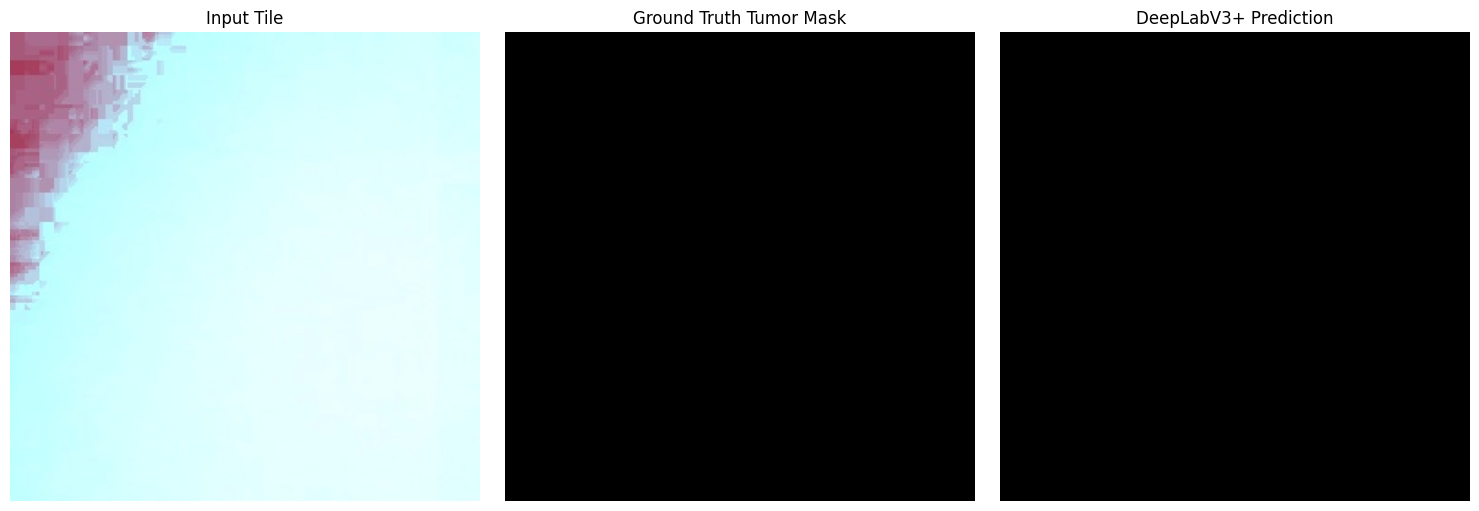

Tile ID: 2cd038d5c85feb0a8da44407e4fb6a5a_x27392_y256
True tumor pixels: 0
Predicted tumor pixels: 0
True tumor fraction: 0.0
Predicted tumor fraction: 0.0


In [59]:
import matplotlib.pyplot as plt

# Get one batch from the test set
batch = next(iter(test_loader))

images = batch["image"].to(device)
true_masks = batch["mask"].to(device)

with torch.no_grad():
    logits = best_deeplab(images)
    probs = torch.sigmoid(logits)
    pred_masks = (probs > 0.5).float()

# Select the first sample
idx = 0

image = images[idx].cpu().numpy()
true_mask = true_masks[idx, 0].cpu().numpy()
pred_mask = pred_masks[idx, 0].cpu().numpy()

# Undo ImageNet normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = np.transpose(image, (1, 2, 0))
image = image * std + mean
image = np.clip(image, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Input Tile")
axes[0].axis("off")

axes[1].imshow(true_mask, cmap="gray")
axes[1].set_title("Ground Truth Tumor Mask")
axes[1].axis("off")

axes[2].imshow(pred_mask, cmap="gray")
axes[2].set_title("DeepLabV3+ Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Tile ID:", batch["tile_id"][idx])
print("True tumor pixels:", int(true_mask.sum()))
print("Predicted tumor pixels:", int(pred_mask.sum()))
print("True tumor fraction:", round(true_mask.mean(), 4))
print("Predicted tumor fraction:", round(pred_mask.mean(), 4))

Tumor-positive test tiles: 526


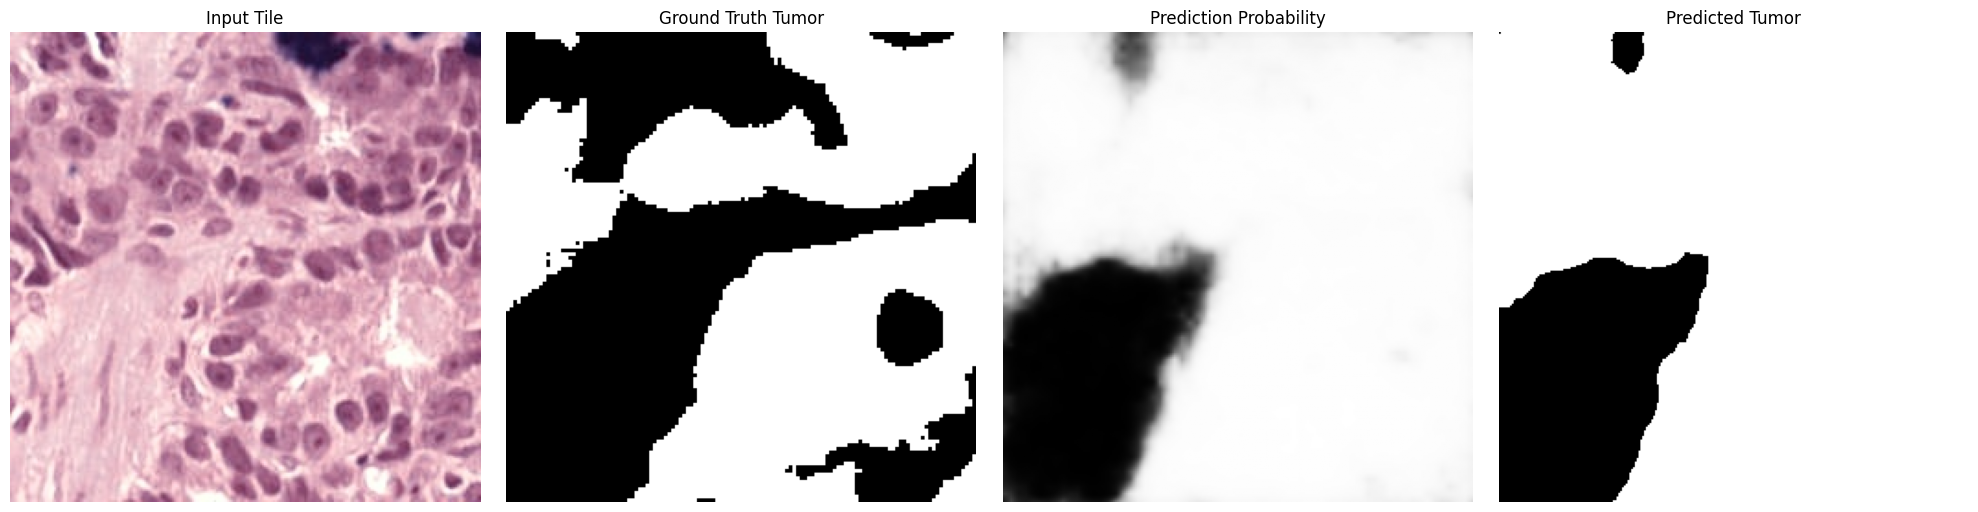

Tile ID: 2cd038d5c85feb0a8da44407e4fb6a5a_x25344_y1024
True tumor pixels: 35076
Predicted tumor pixels: 53892
True tumor fraction: 0.5352
Predicted tumor fraction: 0.8223


In [60]:
# Visualize a test tile that contains tumor

positive_indices = test_df.index[test_df["tile_label"] == 1].tolist()

print("Tumor-positive test tiles:", len(positive_indices))

# Take the first tumor-positive tile
row_index = positive_indices[0]
sample_row = test_df.loc[row_index]

sample_dataset = PathoScopeSegmentationDataset(
    test_df.loc[[row_index]],
    NORM_DIR,
    MASK_DIR,
    augment=False
)

sample = sample_dataset[0]

image = sample["image"].unsqueeze(0).to(device)
true_mask = sample["mask"][0].numpy()

with torch.no_grad():
    logits = best_deeplab(image)
    probability = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred_mask = (probability > 0.5).astype(np.float32)

# Undo ImageNet normalization
image_display = sample["image"].numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_display = np.transpose(image_display, (1, 2, 0))
image_display = image_display * std + mean
image_display = np.clip(image_display, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_display)
axes[0].set_title("Input Tile")
axes[0].axis("off")

axes[1].imshow(true_mask, cmap="gray")
axes[1].set_title("Ground Truth Tumor")
axes[1].axis("off")

axes[2].imshow(probability, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Prediction Probability")
axes[2].axis("off")

axes[3].imshow(pred_mask, cmap="gray")
axes[3].set_title("Predicted Tumor")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("Tile ID:", sample["tile_id"])
print("True tumor pixels:", int(true_mask.sum()))
print("Predicted tumor pixels:", int(pred_mask.sum()))
print("True tumor fraction:", round(true_mask.mean(), 4))
print("Predicted tumor fraction:", round(pred_mask.mean(), 4))

In [61]:
# Calculate sample-level Dice and IoU for the displayed tumor tile

true_binary = true_mask.astype(np.float32)
pred_binary = pred_mask.astype(np.float32)

intersection = np.sum(true_binary * pred_binary)

dice_sample = (
    2 * intersection + 1e-7
) / (
    true_binary.sum() + pred_binary.sum() + 1e-7
)

union = (
    true_binary.sum()
    + pred_binary.sum()
    - intersection
)

iou_sample = (
    intersection + 1e-7
) / (union + 1e-7)

print("Tile ID:", sample["tile_id"])
print("Sample Dice:", round(float(dice_sample), 4))
print("Sample IoU:", round(float(iou_sample), 4))
print("True tumor fraction:", round(float(true_binary.mean()), 4))
print("Predicted tumor fraction:", round(float(pred_binary.mean()), 4))

Tile ID: 2cd038d5c85feb0a8da44407e4fb6a5a_x25344_y1024
Sample Dice: 0.7882
Sample IoU: 0.6504
True tumor fraction: 0.5352
Predicted tumor fraction: 0.8223


In [62]:
import cv2

# Convert predicted tumor mask to uint8
pred_mask_uint8 = (pred_mask > 0).astype(np.uint8)

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    pred_mask_uint8,
    connectivity=8
)

print("Total connected components including background:", num_labels)
print("Predicted foreground components:", num_labels - 1)

# Display component areas
component_areas = stats[1:, cv2.CC_STAT_AREA]

if len(component_areas) > 0:
    print("Largest component area:", int(component_areas.max()))
    print("Smallest component area:", int(component_areas.min()))
    print("Mean component area:", round(float(component_areas.mean()), 2))
else:
    print("No foreground components detected.")

Total connected components including background: 2
Predicted foreground components: 1
Largest component area: 53892
Smallest component area: 53892
Mean component area: 53892.0


In [63]:
# Extract bounding boxes for predicted tumor components

min_area = 100  # remove very small isolated components

detections = []

for component_id in range(1, num_labels):
    x = stats[component_id, cv2.CC_STAT_LEFT]
    y = stats[component_id, cv2.CC_STAT_TOP]
    w = stats[component_id, cv2.CC_STAT_WIDTH]
    h = stats[component_id, cv2.CC_STAT_HEIGHT]
    area = stats[component_id, cv2.CC_STAT_AREA]

    if area >= min_area:
        detections.append({
            "component_id": component_id,
            "x": int(x),
            "y": int(y),
            "width": int(w),
            "height": int(h),
            "area": int(area)
        })

bbox_df = pd.DataFrame(detections)

print("Minimum component area:", min_area)
print("Detected lesions:", len(bbox_df))

display(bbox_df)

Minimum component area: 100
Detected lesions: 1


,component_id,x,y,width,height,area
0,1,0,0,256,256,53892


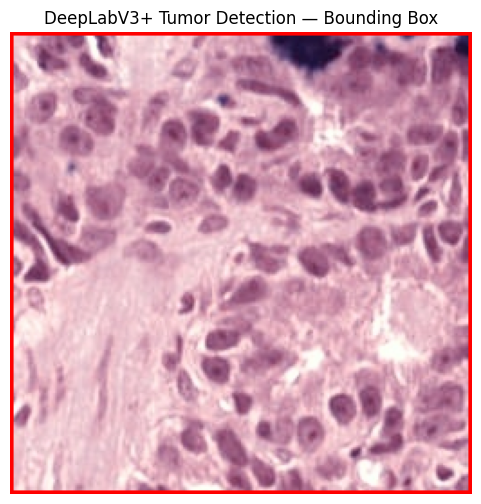

Number of detected lesions: 1
Component 1: x=0, y=0, width=256, height=256, area=53892


In [64]:
# Draw the detected bounding box on the original tile

bbox_image = (image_display * 255).astype(np.uint8).copy()

for detection in detections:
    x = detection["x"]
    y = detection["y"]
    w = detection["width"]
    h = detection["height"]

    cv2.rectangle(
        bbox_image,
        (x, y),
        (x + w - 1, y + h - 1),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(6, 6))
plt.imshow(bbox_image)
plt.title("DeepLabV3+ Tumor Detection — Bounding Box")
plt.axis("off")
plt.show()

print("Number of detected lesions:", len(detections))

for detection in detections:
    print(
        f"Component {detection['component_id']}: "
        f"x={detection['x']}, "
        f"y={detection['y']}, "
        f"width={detection['width']}, "
        f"height={detection['height']}, "
        f"area={detection['area']}"
    )

In [65]:
# Quantify tumor area and lesion count for the current tile

tile_area = pred_mask.shape[0] * pred_mask.shape[1]

tumor_pixels = int(pred_mask.sum())

tumor_area_percent = (
    tumor_pixels / tile_area
) * 100

lesion_count = len(detections)

quantification = pd.DataFrame([{
    "tile_id": sample["tile_id"],
    "tile_area_pixels": tile_area,
    "tumor_area_pixels": tumor_pixels,
    "tumor_area_percent": tumor_area_percent,
    "lesion_count": lesion_count
}])

display(quantification)

print(
    f"Tumor area: {tumor_area_percent:.2f}%"
)

print(
    f"Lesion count: {lesion_count}"
)

,tile_id,tile_area_pixels,tumor_area_pixels,tumor_area_percent,lesion_count
0,2cd038d5c85feb0a8da44407e4fb6a5a_x25344_y1024,65536,53892,82.232666,1


Tumor area: 82.23%
Lesion count: 1


In [66]:
# Quantification across the complete test set

best_deeplab.eval()

all_quantification = []

min_area = 100

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device, non_blocking=True)

        logits = best_deeplab(images)
        probabilities = torch.sigmoid(logits)
        predicted_masks = (probabilities > 0.5).cpu().numpy().astype(np.uint8)

        for i in range(len(predicted_masks)):
            tile_id = batch["tile_id"][i]

            mask = predicted_masks[i, 0]

            tile_height, tile_width = mask.shape
            tile_area = tile_height * tile_width

            tumor_pixels = int(mask.sum())

            tumor_area_percent = (
                tumor_pixels / tile_area
            ) * 100

            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
                mask,
                connectivity=8
            )

            lesion_count = 0

            for component_id in range(1, num_labels):
                component_area = stats[
                    component_id,
                    cv2.CC_STAT_AREA
                ]

                if component_area >= min_area:
                    lesion_count += 1

            all_quantification.append({
                "tile_id": tile_id,
                "tumor_area_pixels": tumor_pixels,
                "tumor_area_percent": tumor_area_percent,
                "lesion_count": lesion_count
            })

quantification_test_df = pd.DataFrame(all_quantification)

print("Test tiles processed:", len(quantification_test_df))
print("Total detected lesions:", int(
    quantification_test_df["lesion_count"].sum()
))

print(
    "Mean predicted tumor area:",
    round(
        quantification_test_df["tumor_area_percent"].mean(),
        4
    ),
    "%"
)

print(
    "Median predicted tumor area:",
    round(
        quantification_test_df["tumor_area_percent"].median(),
        4
    ),
    "%"
)

print(
    "Tiles with predicted tumor:",
    int(
        (quantification_test_df["tumor_area_pixels"] > 0).sum()
    )
)

print(
    "Tiles with no predicted tumor:",
    int(
        (quantification_test_df["tumor_area_pixels"] == 0).sum()
    )
)

display(quantification_test_df.head(10))

Test tiles processed: 1920
Total detected lesions: 1162
Mean predicted tumor area: 13.2644 %
Median predicted tumor area: 0.0 %
Tiles with predicted tumor: 482
Tiles with no predicted tumor: 1438


,tile_id,tumor_area_pixels,tumor_area_percent,lesion_count
0,2cd038d5c85feb0a8da44407e4fb6a5a_x27392_y256,0,0.000000,0
1,2cd038d5c85feb0a8da44407e4fb6a5a_x27648_y256,0,0.000000,0
2,2cd038d5c85feb0a8da44407e4fb6a5a_x27136_y512,0,0.000000,0
3,2cd038d5c85feb0a8da44407e4fb6a5a_x27392_y512,0,0.000000,0
4,2cd038d5c85feb0a8da44407e4fb6a5a_x27648_y512,0,0.000000,0
5,2cd038d5c85feb0a8da44407e4fb6a5a_x27392_y768,0,0.000000,0
6,2cd038d5c85feb0a8da44407e4fb6a5a_x27648_y768,0,0.000000,0
7,2cd038d5c85feb0a8da44407e4fb6a5a_x27904_y768,0,0.000000,0
8,2cd038d5c85feb0a8da44407e4fb6a5a_x25344_y1024,53892,82.232666,1
9,2cd038d5c85feb0a8da44407e4fb6a5a_x27392_y1024,0,0.000000,0


In [67]:
# Save Notebook 04 quantification results

RESULTS_DIR = Path("/content/drive/MyDrive/PathoScope/data/notebook_04_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

quantification_csv = RESULTS_DIR / "segmentation_quantification_test.csv"

quantification_test_df.to_csv(
    quantification_csv,
    index=False
)

print("Quantification results saved.")
print("File:", quantification_csv)
print("Rows:", len(quantification_test_df))
print("Columns:", list(quantification_test_df.columns))

Quantification results saved.
File: /content/drive/MyDrive/PathoScope/data/notebook_04_results/segmentation_quantification_test.csv
Rows: 1920
Columns: ['tile_id', 'tumor_area_pixels', 'tumor_area_percent', 'lesion_count']


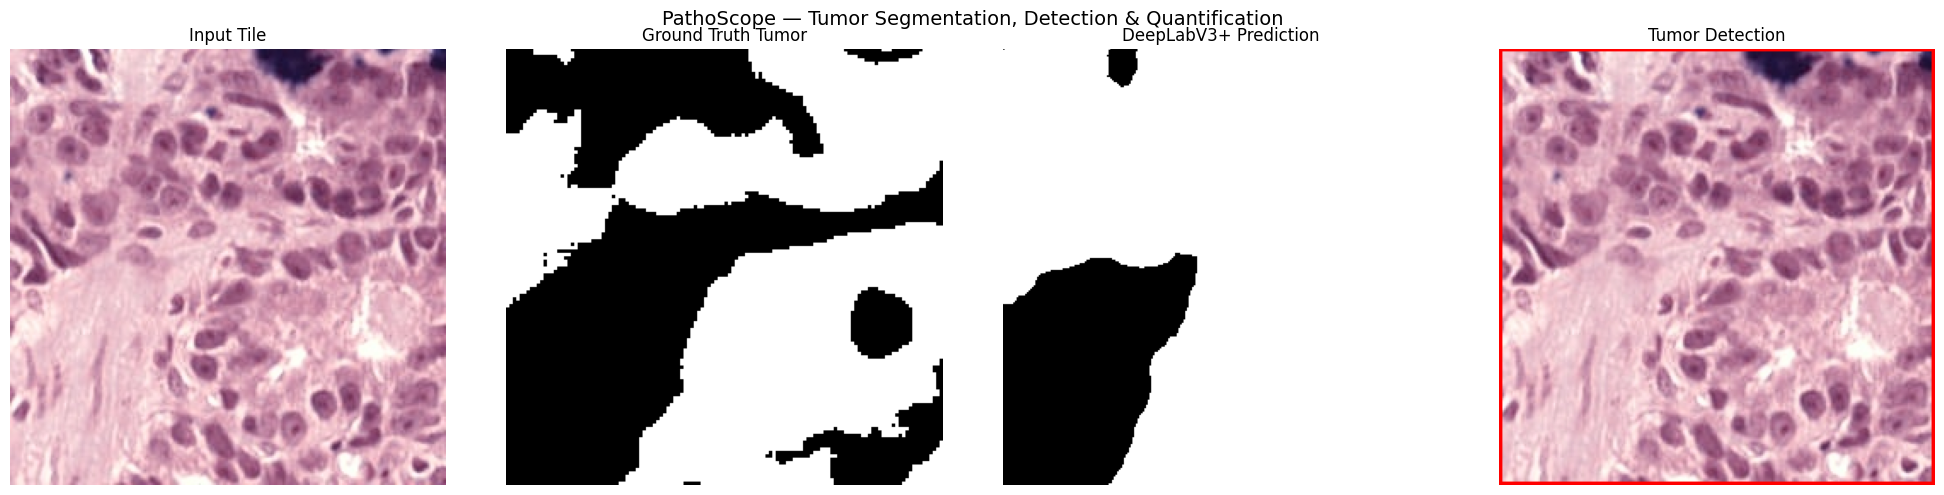

Figure saved:
/content/drive/MyDrive/PathoScope/data/notebook_04_results/fig_04_segmentation.png
Tumor area: 82.23%
Lesion count: 1


In [68]:
# Create the final segmentation, detection and quantification figure

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Input
axes[0].imshow(image_display)
axes[0].set_title("Input Tile")
axes[0].axis("off")

# Ground truth
axes[1].imshow(true_mask, cmap="gray")
axes[1].set_title("Ground Truth Tumor")
axes[1].axis("off")

# Prediction
axes[2].imshow(pred_mask, cmap="gray")
axes[2].set_title("DeepLabV3+ Prediction")
axes[2].axis("off")

# Detection
detection_image = (image_display * 255).astype(np.uint8).copy()

for detection in detections:
    x = detection["x"]
    y = detection["y"]
    w = detection["width"]
    h = detection["height"]

    cv2.rectangle(
        detection_image,
        (x, y),
        (x + w - 1, y + h - 1),
        (255, 0, 0),
        2
    )

axes[3].imshow(detection_image)
axes[3].set_title("Tumor Detection")
axes[3].axis("off")

plt.suptitle(
    "PathoScope — Tumor Segmentation, Detection & Quantification",
    fontsize=14
)

plt.tight_layout()

fig04_path = RESULTS_DIR / "fig_04_segmentation.png"

plt.savefig(
    fig04_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(fig04_path)

print(f"Tumor area: {pred_mask.mean() * 100:.2f}%")
print(f"Lesion count: {len(detections)}")

In [69]:
import json
import shutil

# Save model comparison
comparison_path = RESULTS_DIR / "segmentation_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)

# Save final metrics
final_metrics = {
    "selected_model": "DeepLabV3Plus + ResNet34",
    "validation_dice": 0.8097462289036592,
    "validation_iou": 0.7952667223911762,
    "test_loss": 0.5024,
    "test_dice": 0.8453,
    "test_iou": 0.8278,
    "test_tiles": 1920,
    "predicted_tumor_tiles": 482,
    "non_tumor_predicted_tiles": 1438,
    "mean_predicted_tumor_area_percent": 13.2644,
    "median_predicted_tumor_area_percent": 0.0,
    "total_tile_level_lesion_components": 1162,
    "minimum_component_area": 100
}

metrics_path = RESULTS_DIR / "segmentation_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

# Backup trained checkpoints to Google Drive
checkpoint_files = [
    "unet.pth",
    "unet_resnet50.pth",
    "unetpp_resnet34.pth",
    "deeplabv3plus_resnet34.pth"
]

for filename in checkpoint_files:
    source = WORK_DIR / filename
    destination = RESULTS_DIR / filename

    if source.exists():
        shutil.copy2(source, destination)
        print("Backed up:", filename)
    else:
        print("Not found:", filename)

print("\nNotebook 04 final files saved to:")
print(RESULTS_DIR)

print("\nComparison:", comparison_path)
print("Metrics:", metrics_path)
print("Figure:", RESULTS_DIR / "fig_04_segmentation.png")

Backed up: unet.pth
Backed up: unet_resnet50.pth
Backed up: unetpp_resnet34.pth
Backed up: deeplabv3plus_resnet34.pth

Notebook 04 final files saved to:
/content/drive/MyDrive/PathoScope/data/notebook_04_results

Comparison: /content/drive/MyDrive/PathoScope/data/notebook_04_results/segmentation_model_comparison.csv
Metrics: /content/drive/MyDrive/PathoScope/data/notebook_04_results/segmentation_metrics.json
Figure: /content/drive/MyDrive/PathoScope/data/notebook_04_results/fig_04_segmentation.png
